#### **1. Selecciona un dataset público de Kaggle** 
Que contenga variables numéricas y categóricas. (Puedes consultar con el docente si tienes dudas sobre la elección).

In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

#### **2. Realiza el preprocesamiento del dataset en un notebook, incluyendo:**

+ Limpieza de datos (eliminación o imputación de valores nulos
y/o atípicos).
+ Conversión y codificación de variables categóricas.
+ Estandarización o normalización de variables numéricas (solo
con Pandas o NumPy, no sklearn).
+ Visualización inicial para explorar la información y justificar tus
decisiones. 

In [259]:
df=pd.read_csv('Telco_Customer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### **2.1 Limpieza de columnas innecesarias**

In [260]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

El dataset contiene información demográfica, de servicios contratados y de facturación de clientes de telecomunicaciones. Incluye variables categóricas (por ejemplo, gender, Contract, PaymentMethod), variables numéricas (tenure, MonthlyCharges, TotalCharges) y una variable objetivo original (Churn) que indica si el cliente abandonó el servicio.

In [261]:
df=df.drop(columns =['customerID', 'gender', 'Partner', 'Dependents', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies', 'PhoneService', 'MultipleLines']).copy()

display(df.sample(5))

,SeniorCitizen,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4405,0,6,Fiber optic,No,No,Month-to-month,Yes,Credit card (automatic),83.55,477.55,Yes
4363,0,56,Fiber optic,No,No,Month-to-month,Yes,Bank transfer (automatic),85.60,4902.8,No
535,0,12,Fiber optic,No,No,Month-to-month,Yes,Electronic check,89.55,1021.75,No
769,0,17,DSL,Yes,No,One year,No,Mailed check,64.80,1175.6,No
6941,0,61,DSL,Yes,Yes,One year,Yes,Bank transfer (automatic),50.70,3088.75,No


Se eliminan variables que no aportan información predictiva directa (customerID) o que presentan alta redundancia con otras variables del servicio.

In [262]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   tenure            7043 non-null   int64  
 2   InternetService   7043 non-null   object 
 3   OnlineSecurity    7043 non-null   object 
 4   TechSupport       7043 non-null   object 
 5   Contract          7043 non-null   object 
 6   PaperlessBilling  7043 non-null   object 
 7   PaymentMethod     7043 non-null   object 
 8   MonthlyCharges    7043 non-null   float64
 9   TotalCharges      7043 non-null   object 
 10  Churn             7043 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 605.4+ KB


El dataset contiene 7043 registros y 11 variables. Se identifican variables numéricas (SeniorCitizen, tenure, MonthlyCharges) y varias variables categóricas de tipo object.

In [263]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [264]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [265]:
cat_col=df.select_dtypes(include=['object']).columns
cat_col


Index(['InternetService', 'OnlineSecurity', 'TechSupport', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

Se identifican las variables categóricas del dataset utilizando el tipo de dato object

In [266]:
df[cat_col]=df[cat_col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7043 non-null   int64   
 1   tenure            7043 non-null   int64   
 2   InternetService   7043 non-null   category
 3   OnlineSecurity    7043 non-null   category
 4   TechSupport       7043 non-null   category
 5   Contract          7043 non-null   category
 6   PaperlessBilling  7043 non-null   category
 7   PaymentMethod     7043 non-null   category
 8   MonthlyCharges    7043 non-null   float64 
 9   TotalCharges      7032 non-null   float64 
 10  Churn             7043 non-null   category
dtypes: category(7), float64(2), int64(2)
memory usage: 269.3 KB


Las variables categóricas se convierten al tipo category para facilitar su identificación y análisis

In [267]:
num_col=df.select_dtypes(include=['int64','float64']).columns #pro prositos didacticos
 
df[num_col].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


##### **2.2 Valores nulos (missing values)**


In [268]:
nulls=df.isna().sum().sort_values(ascending=False)  
nulls

TotalCharges        11
SeniorCitizen        0
tenure               0
InternetService      0
OnlineSecurity       0
TechSupport          0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

Se observa la presencia de valores nulos únicamente en la variable TotalCharges, mientras que el resto de las variables no presentan datos faltantes.

##### **2.3 Registros inválidos en dimensiones (tenure, TotalCharges, MontlyCharges)**

Verifique cuántas filas tienen `tenure=0`, `MontlyCharges=0` o `TotalCharges=0`.  
Luego, elimine esas filas (o defina otra estrategia).

In [269]:
print("Filas con tenure=0: ",(df['tenure']==0).sum())
print("Filas con MonthlyCharges=0: ",(df['MonthlyCharges']==0).sum())
print("Filas con TotalCharges=0: ",(df['TotalCharges']==0).sum())

Filas con tenure=0:  11
Filas con MonthlyCharges=0:  0
Filas con TotalCharges=0:  0


Eliminar es mejor que imputar en este caso porque:
- Los clientes con no tienen historial ni cargos reales.
- Imputar  sería artificial y poco representativo.
- Solo se pierden 11 filas de más de 7000 → impacto mínimo.


In [270]:
mask_z=(df['tenure']==0 )

values_z=df[mask_z]

display(values_z)

print(values_z.shape)

,SeniorCitizen,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,0,0,DSL,Yes,Yes,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,0,0,No,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,0,0,DSL,Yes,No,Two year,No,Mailed check,80.85,NaN,No
1082,0,0,No,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,0,0,DSL,Yes,Yes,Two year,No,Credit card (automatic),56.05,NaN,No
3331,0,0,No,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,0,0,No,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,0,0,No,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,0,0,No,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,0,0,DSL,No,Yes,Two year,No,Mailed check,73.35,NaN,No


(11, 11)


##### **2.4 Detección y tratamiento de outliers (IQR)**
1) Grafique boxplots de `tenure`, `MonthlyCharges`.  
2) Calcule límites IQR para esas variables.  
3) Aplique una estrategia (recomendado: recorte con `clip`) o elimine outliers y justifique su decisión.


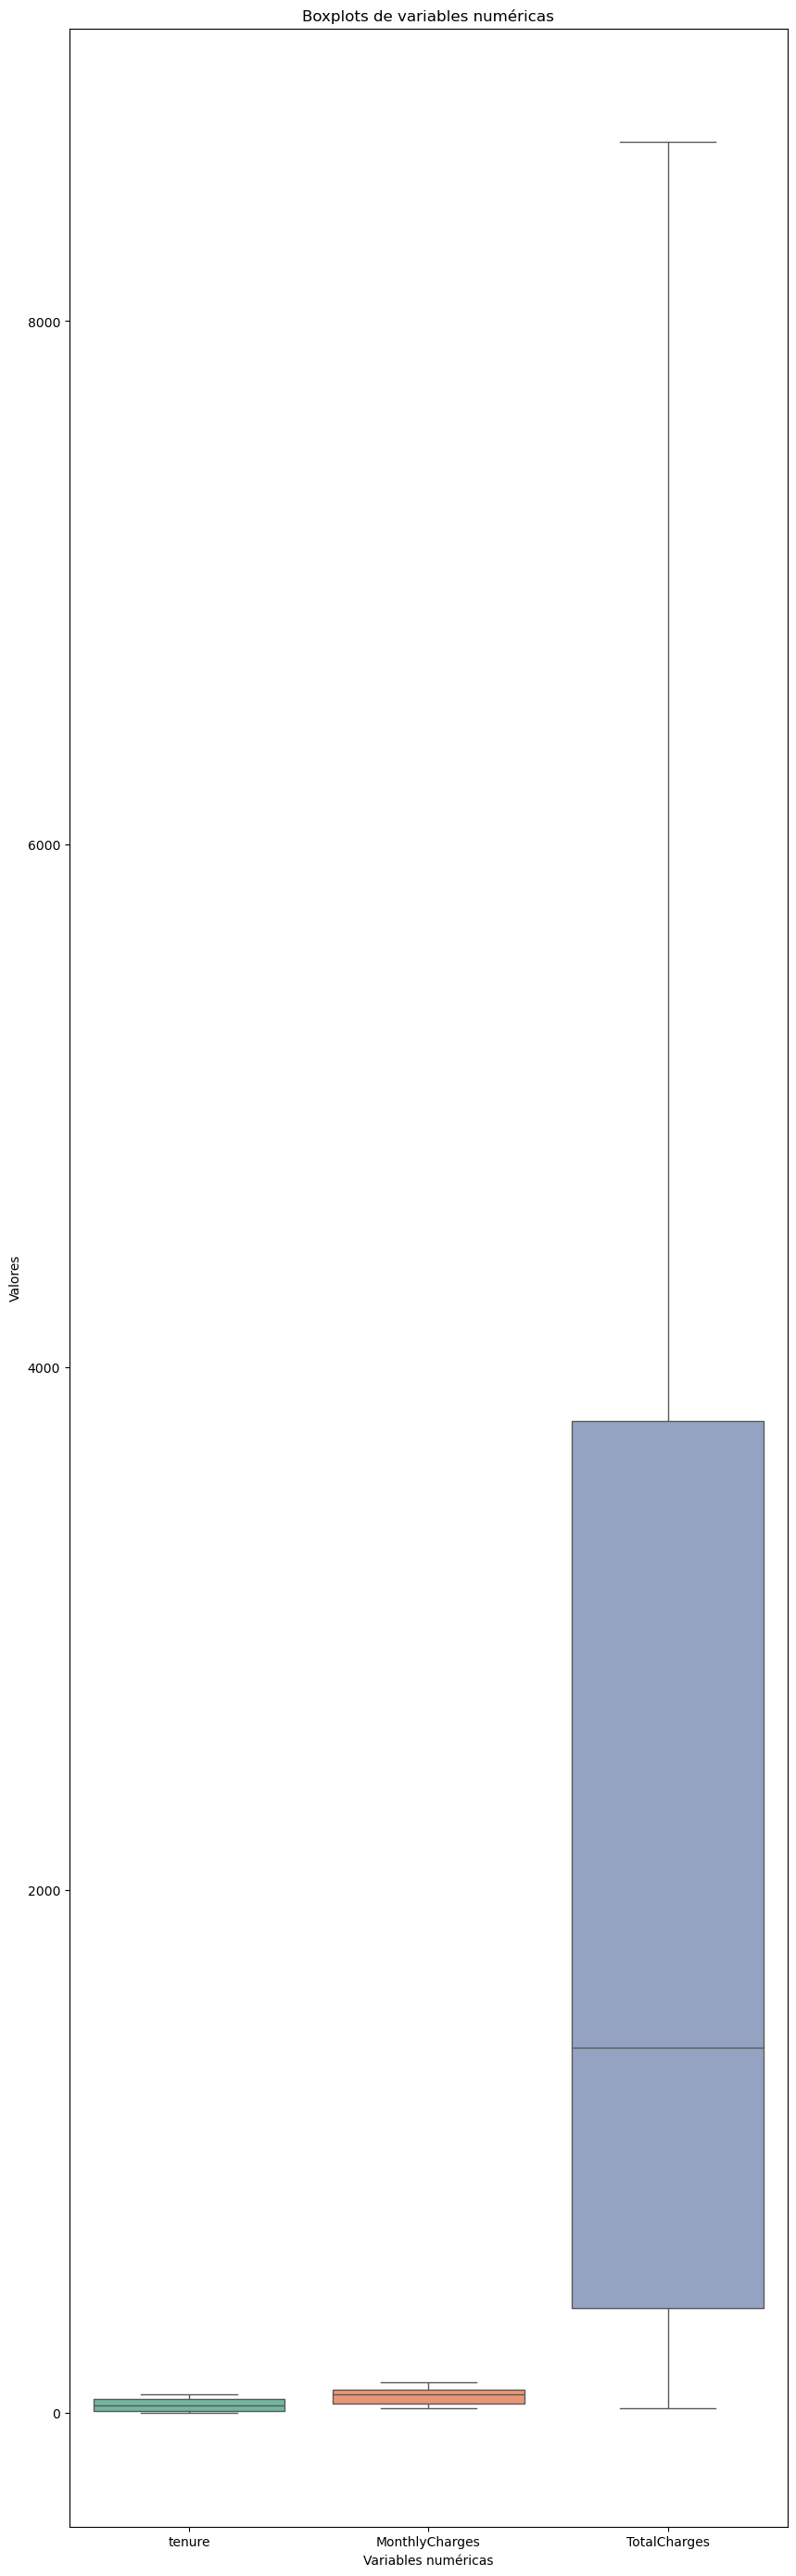

In [271]:
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(10,35))
sns.boxplot(data=df[num_vars], palette="Set2")
plt.title("Boxplots de variables numéricas")
plt.xlabel("Variables numéricas")
plt.ylabel("Valores")
plt.show()


Se analizan las principales variables numéricas del dataset (tenure, MonthlyCharges y TotalCharges) mediante boxplots para identificar posibles valores atípicos

**Límites IQR**

In [272]:
for col in num_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5*IQR
    lim_sup = Q3 + 1.5*IQR
    print(f"{col}: IQR={IQR:.2f}, Lower={lim_inf:.2f}, Upper={lim_sup:.2f}")

tenure: IQR=46.00, Lower=-60.00, Upper=124.00
MonthlyCharges: IQR=54.35, Lower=-46.02, Upper=171.38
TotalCharges: IQR=3393.29, Lower=-4688.48, Upper=8884.67


El análisis mediante el (IQR) muestra que las variables tenure, MonthlyCharges y TotalCharges no presentan valores atípicos significativos.

In [273]:
n=len(df)
k=int(1+np.log2(n))
k

13

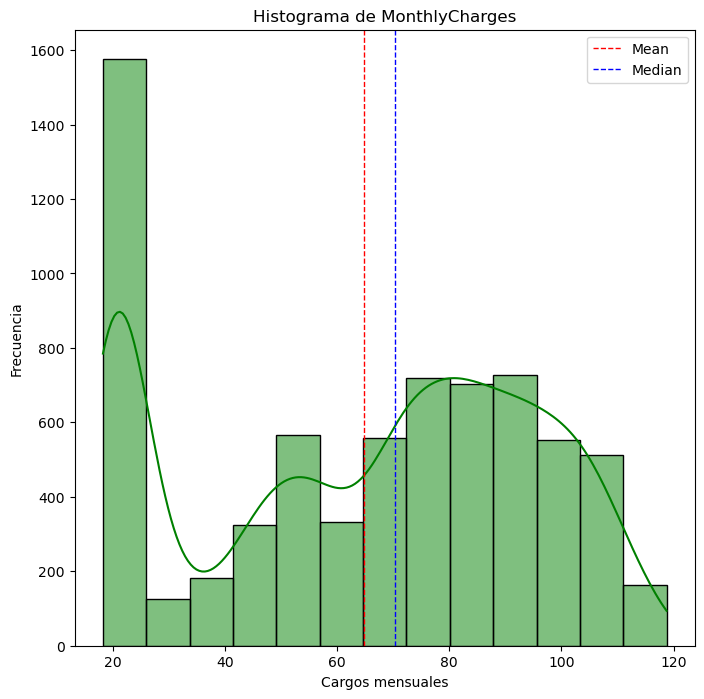

In [274]:
plt.figure(figsize=(8,8))
sns.histplot(df['MonthlyCharges'], bins=k, color='green', kde=True)

# Líneas de media y mediana
plt.axvline(df['MonthlyCharges'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['MonthlyCharges'].median(), color='blue', linestyle='dashed', linewidth=1, label='Median')

plt.title('Histograma de MonthlyCharges')
plt.xlabel('Cargos mensuales')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

El histograma de **MonthlyCharges** muestra una distribución ligeramente asimétrica, la media y la mediana presentan valores similares, indicando una distribución relativamente equilibrada.

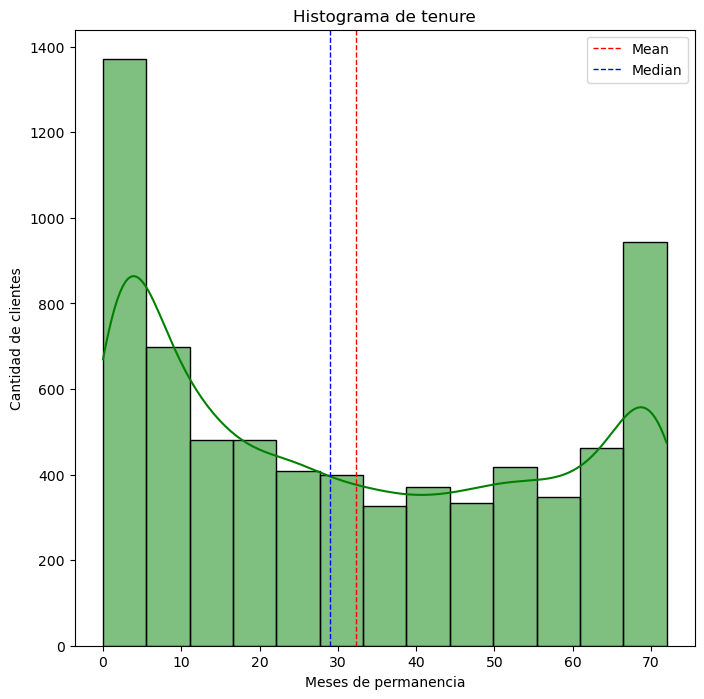

In [275]:
plt.figure(figsize=(8,8))
sns.histplot(df['tenure'], bins=k, color='green', kde=True)

# Líneas de media y mediana
plt.axvline(df['tenure'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['tenure'].median(), color='blue', linestyle='dashed', linewidth=1, label='Median')

plt.title('Histograma de tenure')
plt.xlabel('Meses de permanencia')
plt.ylabel('Cantidad de clientes')
plt.legend()
plt.show()

La variable **tenure** presenta una distribución no uniforme, con concentración en los extremos, lo que sugiere la coexistencia de clientes recientemente incorporados y clientes fidelizados

In [276]:
df_100=df.sample(1000, random_state=42)

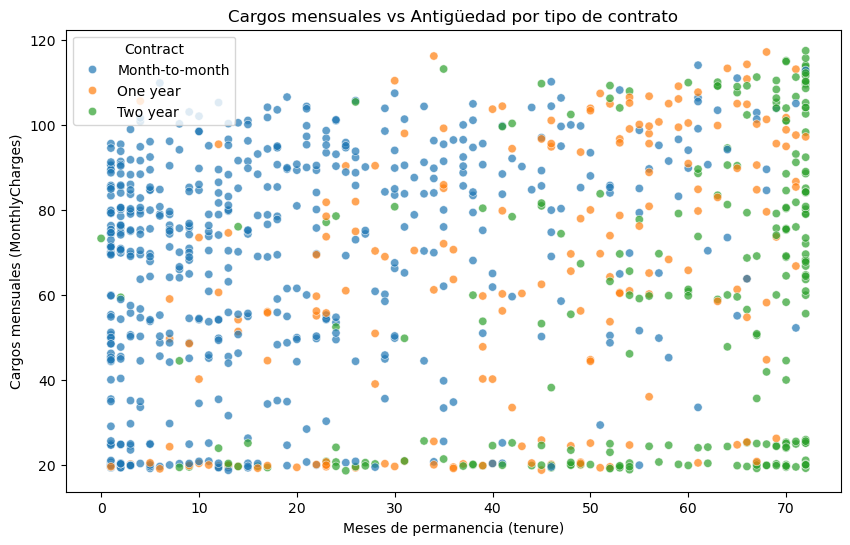

In [277]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_100, x='tenure', y='MonthlyCharges', hue='Contract', alpha=0.7)

plt.title('Cargos mensuales vs Antigüedad por tipo de contrato')
plt.xlabel('Meses de permanencia (tenure)')
plt.ylabel('Cargos mensuales (MonthlyCharges)')
plt.legend(title='Contract')
plt.show()

El gráfico de dispersión muestra que no existe una relación lineal clara entre la antigüedad del cliente **tenure** y los cargos mensuales **MonthlyCharges**. Sin embargo, al diferenciar por tipo de contrato **Contract**, se observan patrones claros: los clientes con **contratos mensuales** se concentran en valores bajos de permanencia, mientras que los contratos de **uno y dos años** se asocian a mayores niveles de antigüedad.

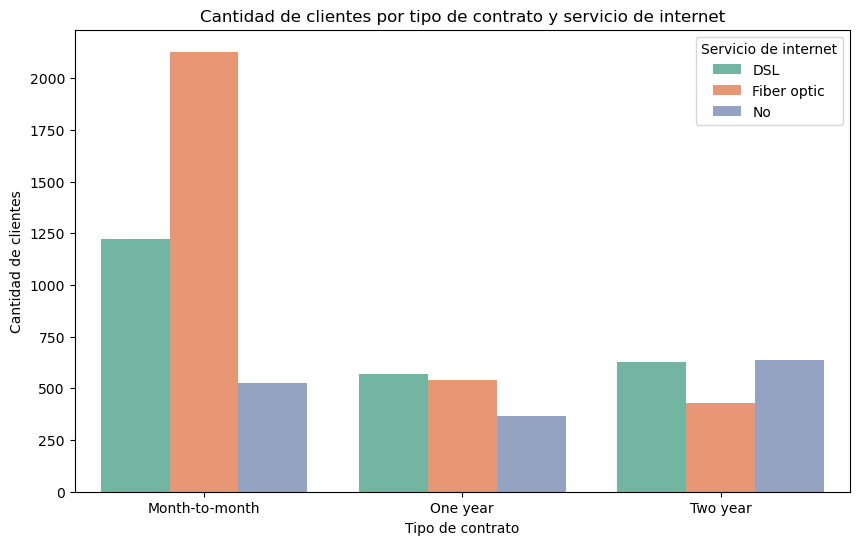

In [278]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Contract', hue='InternetService', palette='Set2')

plt.title('Cantidad de clientes por tipo de contrato y servicio de internet')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Servicio de internet')
plt.show()

El gráfico muestra que la mayoría de los clientes tienen contratos mensuales, especialmente aquellos que utilizan fibra óptica. Los contratos de uno y dos años presentan una menor cantidad de clientes y una mayor proporción de servicios DSL o ausencia de servicio de internet. Este patrón sugiere que los clientes con contratos mensuales y fibra óptica conforman un grupo importante, mientras que los contratos de largo plazo se asocian a mayor estabilidad.

##### **6. Conversión y codificación de variables categóricas (get_dummies)**
Identifique columnas categóricas y conviértalas a variables numéricas usando `pd.get_dummies()` (con `drop_first=True`).


In [279]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7043 non-null   int64   
 1   tenure            7043 non-null   int64   
 2   InternetService   7043 non-null   category
 3   OnlineSecurity    7043 non-null   category
 4   TechSupport       7043 non-null   category
 5   Contract          7043 non-null   category
 6   PaperlessBilling  7043 non-null   category
 7   PaymentMethod     7043 non-null   category
 8   MonthlyCharges    7043 non-null   float64 
 9   TotalCharges      7032 non-null   float64 
 10  Churn             7043 non-null   category
dtypes: category(7), float64(2), int64(2)
memory usage: 269.3 KB


In [280]:
# Revisar nulos
print(df.isnull().sum())

# Imputar nulos en TotalCharges con la media (puedes usar mediana también)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

SeniorCitizen        0
tenure               0
InternetService      0
OnlineSecurity       0
TechSupport          0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [281]:
cat_col

Index(['InternetService', 'OnlineSecurity', 'TechSupport', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [282]:
# Codificación de variables categóricas
df_enc = pd.get_dummies(df, columns=cat_col, dtype=float, drop_first=True)

# Visualizar primeras filas
df_enc.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0,34,56.95,1889.50,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,2,53.85,108.15,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,0,45,42.30,1840.75,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,2,70.70,151.65,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


#### **3. Implementa dos modelos predictivos con scikit-learn:**
- Un modelo de clasificación (eligiendo una variable objetivo
adecuada).
- Un modelo de regresión (sobre una variable numérica del
dataset).
- Puedes usar modelos como: LogisticRegression, LinearRegression,
DecisionTreeClassifier, etc.

#### **4. Analiza los resultados de ambos modelos, mostrando métricas relevantes y visualizaciones.**


In [283]:
def normalize_dataset(df):
    """
    Aplica normalización Min-Max a las variables numéricas del DataFrame.
    La normalización se realiza como: (x - min) / (max - min)

    Parámetros:
    df (pd.DataFrame): DataFrame con variables numéricas

    Retorna:
    pd.DataFrame: DataFrame normalizado
    """
    df_normalized = df.copy()
    min_val = df_normalized.min(axis=0)
    max_val = df_normalized.max(axis=0)
    df_normalized= (df_normalized- min_val) / (max_val - min_val)
    return df_normalized

#Se aplica normalización Min–Max para llevar todas las variables numéricas al rango [0,1], 
# evitando que aquellas con mayor escala dominen el entrenamiento de los modelos

In [284]:
def standardize_dataset(df):
    """
    Aplica estandarización Z-score a las variables numéricas del DataFrame.
    La transformación se realiza como: (x - mean) / std

    Parámetros:
    df (pd.DataFrame): DataFrame con variables numéricas

    Retorna:
    pd.DataFrame: DataFrame estandarizado
    """
    df_standardized = df.copy()
    mean_val = df_standardized.mean(axis=0)
    std_val = df_standardized.std(axis=0)
    df_standardized = (df_standardized - mean_val) / std_val
    return df_standardized

#se utiliza para centrar las variables en media cero y desviación estándar #uno, lo que es especialmente útil para modelos sensibles

In [285]:
num_vars = ['tenure','MonthlyCharges','TotalCharges']

# Normalización Min-Max
df_norm = normalize_dataset(df_enc[num_vars])

# Estandarización Z-score
df_std = standardize_dataset(df_enc[num_vars])

df_norm.head()
df_std.head()

,tenure,MonthlyCharges,TotalCharges
0,-1.277354,-1.160241,-0.994171
1,0.066323,-0.259611,-0.173232
2,-1.236636,-0.362635,-0.959606
3,0.514215,-0.746482,-0.194752
4,-1.236636,0.197351,-0.940403


In [286]:
# Variable objetivo para clasificación (Churn codificada como 0/1)
y_class = df_enc['Churn_Yes']
X_class = df_enc.drop(columns=['Churn_Yes'])

# Variable objetivo para regresión (MonthlyCharges)
y_reg = df_enc['MonthlyCharges']
X_reg = df_enc.drop(columns=['MonthlyCharges'])

# División en train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

##### MODELO 1: **CLASIFICACIÓN**
- Explica la elección de la variable objetivo.
- Divide el dataset en train/test (usa sklearn).
- Entrena el modelo y muestra métricas (accuracy, matriz de confusión, classification report).
- Visualiza los resultados.


Se crea una variable objetivo binaria que clasifica a los clientes según si su cargo mensual es superior al promedio.

In [287]:
df.sample(5)

,SeniorCitizen,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5185,0,50,DSL,Yes,Yes,One year,Yes,Credit card (automatic),70.80,3478.15,No
4872,0,72,DSL,Yes,Yes,Two year,Yes,Bank transfer (automatic),84.90,6065.30,No
4089,0,9,Fiber optic,No,No,Month-to-month,Yes,Electronic check,74.75,706.60,Yes
2185,0,24,DSL,Yes,No,Month-to-month,No,Electronic check,54.75,1338.15,Yes
1441,1,58,Fiber optic,No,No,One year,Yes,Bank transfer (automatic),97.80,5458.80,No


In [288]:
df_norm.sample(5)

,tenure,MonthlyCharges,TotalCharges
2490,0.541667,0.818905,0.447329
6127,0.777778,0.910945,0.702844
1163,0.166667,0.711443,0.119271
5747,0.444444,0.542786,0.267049
6971,0.250000,0.810945,0.209722


##### **3.3 Entrenamiento y evaluación del clasificador**



Accuracy: 0.8112136266855926
              precision    recall  f1-score   support

         0.0       0.85      0.90      0.88      1036
         1.0       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



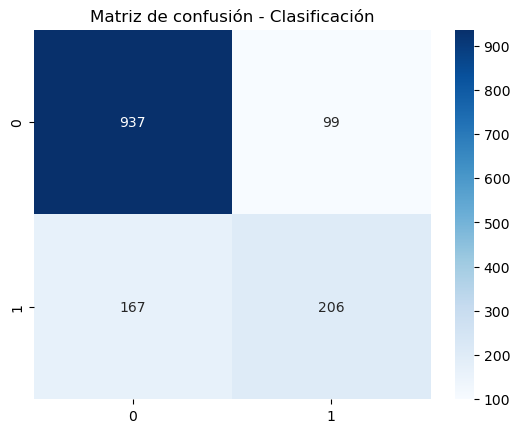

In [292]:
# Entrenamiento del modelo de clasificación
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train_c, y_train_c)

# Predicciones
y_pred_c = clf.predict(X_test_c)

# Métricas
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

# Matriz de confusión
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Clasificación")
plt.show()

El modelo de regresión logística alcanza una accuracy del 81.12 %, lo que indica un alto nivel de acierto en la clasificación

##### MODELO 2: **REGRESIÓN**
**Definición del objetivo (target) de regresión**



MSE: 66.84388571399715
R²: 0.9261699146290785


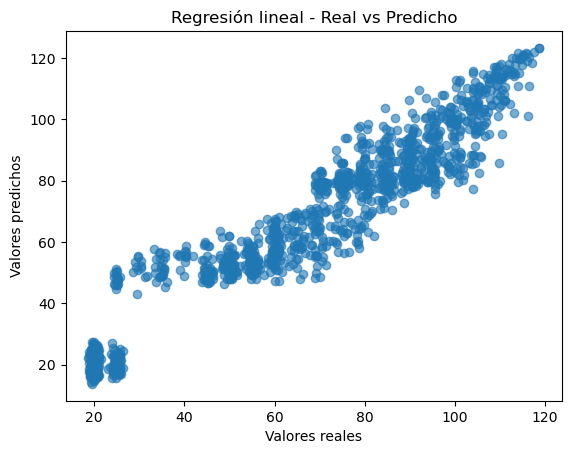

In [291]:
# Entrenamiento del modelo de regresión
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

# Predicciones
y_pred_r = reg.predict(X_test_r)

# Métricas
print("MSE:", mean_squared_error(y_test_r, y_pred_r))
print("R²:", r2_score(y_test_r, y_pred_r))

# Visualización: valores reales vs predichos
plt.scatter(y_test_r, y_pred_r, alpha=0.6)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión lineal - Real vs Predicho")
plt.show()